# 04 — Evaluation & Results

Comprehensive evaluation of all three attribution methods.
Covers Experiments B1, C1-C3, D1-D3.

In [8]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.evaluation_metrics import (
    top_k_accuracy, compute_far_frr, compute_far_frr_curve, compute_eer,
    compute_ece, compute_brier_score, selective_risk,
    compute_confusion_matrix, error_taxonomy, per_device_frr
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [9]:
# Simulate predictions from 3 methods for comparison
rng = np.random.RandomState(42)
N = 500
N_CLASSES = 10

y_true = rng.randint(0, N_CLASSES, N)

# NCC: moderate accuracy
ncc_probs = rng.dirichlet(np.ones(N_CLASSES) * 0.5, N)
for i in range(N):
    if rng.rand() < 0.75:
        ncc_probs[i, y_true[i]] += 2.0
ncc_probs /= ncc_probs.sum(axis=1, keepdims=True)

# CNN: higher accuracy
cnn_probs = rng.dirichlet(np.ones(N_CLASSES) * 0.3, N)
for i in range(N):
    if rng.rand() < 0.88:
        cnn_probs[i, y_true[i]] += 3.0
cnn_probs /= cnn_probs.sum(axis=1, keepdims=True)

# Siamese: similar to CNN
siam_probs = rng.dirichlet(np.ones(N_CLASSES) * 0.3, N)
for i in range(N):
    if rng.rand() < 0.85:
        siam_probs[i, y_true[i]] += 2.5
siam_probs /= siam_probs.sum(axis=1, keepdims=True)

methods = {'NCC': ncc_probs, 'CNN': cnn_probs, 'Siamese': siam_probs}

In [10]:
# Experiment B1: Method Comparison
print('=== Method Comparison (B1) ===')
print(f'{"Method":>10} | {"Top-1":>6} | {"Top-5":>6} | {"ECE":>6} | {"Brier":>6}')
print('-' * 50)

for name, probs in methods.items():
    t1 = top_k_accuracy(y_true, probs, k=1)
    t5 = top_k_accuracy(y_true, probs, k=5)
    ece = compute_ece(y_true, probs)
    brier = compute_brier_score(y_true, probs)
    print(f'{name:>10} | {t1*100:5.1f}% | {t5*100:5.1f}% | {ece:.4f} | {brier:.4f}')

=== Method Comparison (B1) ===
    Method |  Top-1 |  Top-5 |    ECE |  Brier
--------------------------------------------------
       NCC |  75.8% |  87.6% | 0.2918 | 0.3700
       CNN |  87.4% |  93.0% | 0.2278 | 0.2218
   Siamese |  86.2% |  92.6% | 0.2524 | 0.2509


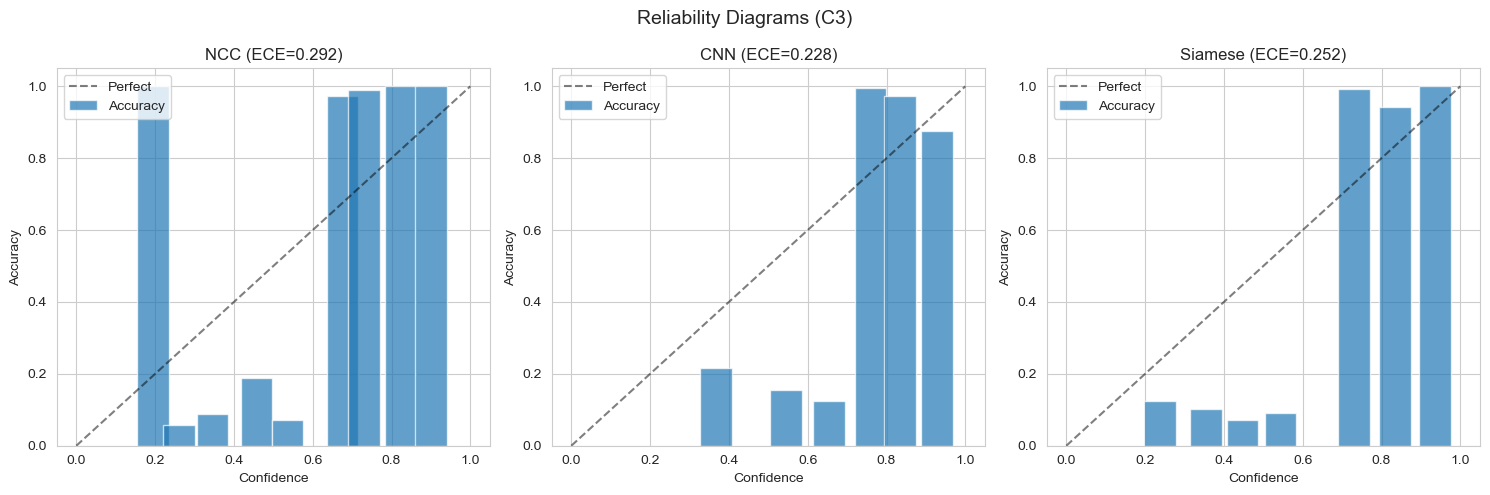

In [11]:
# Experiment C3: Calibration
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, probs) in zip(axes, methods.items()):
    confs = np.max(probs, axis=1)
    preds = np.argmax(probs, axis=1)
    accs = (preds == y_true).astype(float)
    
    bins = np.linspace(0, 1, 11)
    bin_accs, bin_confs = [], []
    for i in range(len(bins)-1):
        mask = (confs > bins[i]) & (confs <= bins[i+1])
        if mask.sum() > 0:
            bin_accs.append(accs[mask].mean())
            bin_confs.append(confs[mask].mean())
    
    ax.bar(bin_confs, bin_accs, width=0.08, alpha=0.7, label='Accuracy')
    ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Perfect')
    ax.set_title(f'{name} (ECE={compute_ece(y_true, probs):.3f})')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.suptitle('Reliability Diagrams (C3)', fontsize=14)
plt.tight_layout()
plt.show()

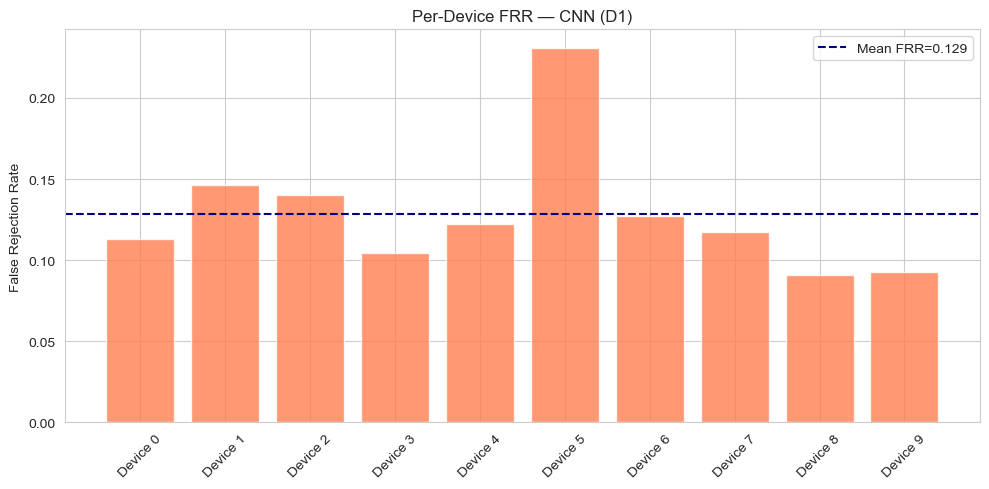

In [12]:
# Experiment D1: Per-device FRR
y_pred_cnn = np.argmax(cnn_probs, axis=1)
frr = per_device_frr(y_true, y_pred_cnn)

plt.figure(figsize=(10, 5))
devices = sorted(frr.keys())
frr_values = [frr[d] for d in devices]
plt.bar([f'Device {d}' for d in devices], frr_values, color='coral', alpha=0.8)
plt.axhline(y=np.mean(frr_values), color='navy', linestyle='--', label=f'Mean FRR={np.mean(frr_values):.3f}')
plt.ylabel('False Rejection Rate')
plt.title('Per-Device FRR — CNN (D1)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

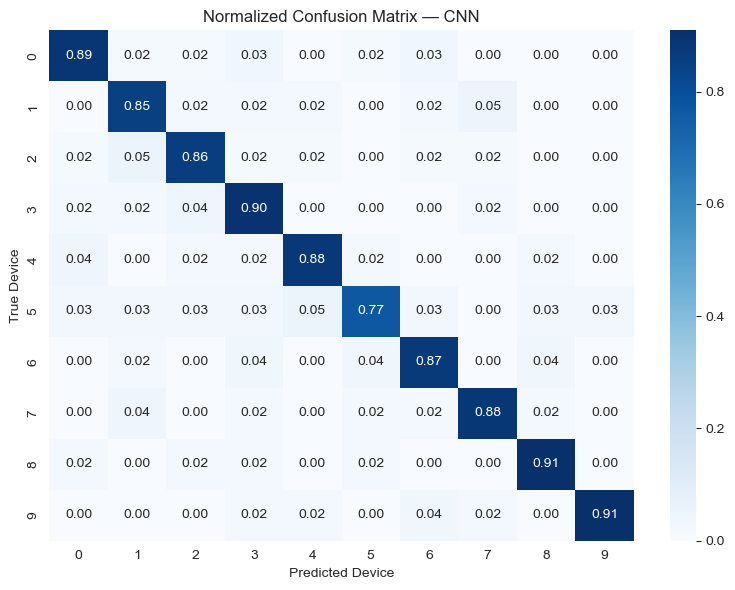


Error Taxonomy:
  total_errors: 63
  same_model_errors: 8
  cross_model_errors: 55
  same_model_rate: 0.12698412698412698


In [13]:
# Experiment D2: Confusion Matrix & Error Taxonomy
device_to_model = {i: f'Model_{i//2}' for i in range(N_CLASSES)}

cm = compute_confusion_matrix(y_true, y_pred_cnn, normalize='true')
taxonomy = error_taxonomy(y_true, y_pred_cnn, device_to_model)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted Device')
ax.set_ylabel('True Device')
ax.set_title('Normalized Confusion Matrix — CNN')
plt.tight_layout()
plt.show()

print(f'\nError Taxonomy:')
for k, v in taxonomy.items():
    print(f'  {k}: {v}')

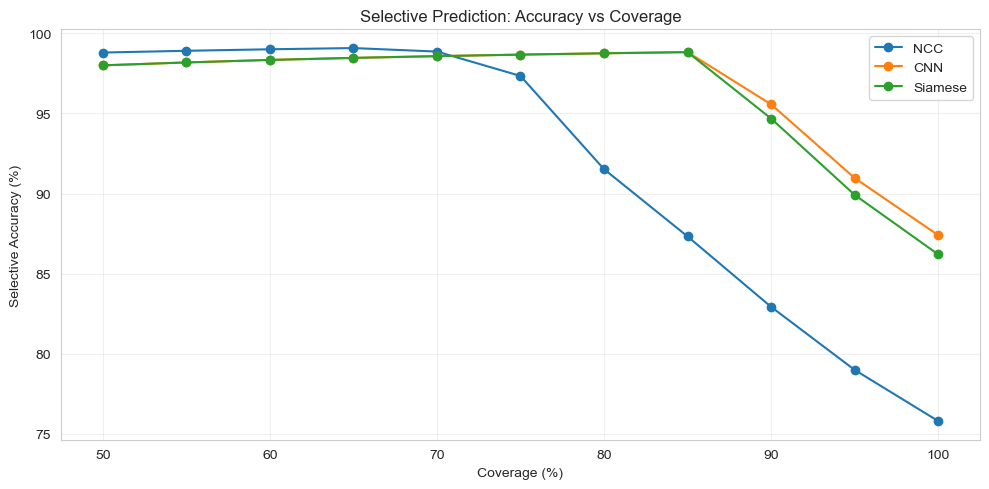

In [14]:
# Selective Risk (abstention curve)
coverages = np.arange(0.5, 1.01, 0.05)

plt.figure(figsize=(10, 5))
for name, probs in methods.items():
    accs = [selective_risk(y_true, probs, c)[0] for c in coverages]
    plt.plot(coverages * 100, [a*100 for a in accs], 'o-', label=name)

plt.xlabel('Coverage (%)')
plt.ylabel('Selective Accuracy (%)')
plt.title('Selective Prediction: Accuracy vs Coverage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()